In [3]:
def season_ranking_expectation(match, standings):
    """
    Predict match winner based on season-end rankings.

    Args:
        match: Single match row with season, home_team, away_team columns
        standings: DataFrame with season, team_name, rank columns

    Returns:
        +1 for expected home win, -1 for expected away win, 0 if unable to determine
    """
    try:
        season = match.season
        hometeam = match.home_team
        awayteam = match.away_team

        # Get rankings with error handling
        home_rank_data = standings.loc[(standings['season'] == season) & (standings['team_name'] == hometeam), 'rank']
        away_rank_data = standings.loc[(standings['season'] == season) & (standings['team_name'] == awayteam), 'rank']

        # Check if rankings exist
        if home_rank_data.empty or away_rank_data.empty:
            return 0  # Unable to predict

        homestanding = home_rank_data.iloc[0]
        awaystanding = away_rank_data.iloc[0]

        # Handle NaN values
        if pd.isna(homestanding) or pd.isna(awaystanding):
            return 0

        # Lower rank number = better team
        if homestanding < awaystanding:
            return 1  # Home team expected to win
        else:
            return -1  # Away team expected to win

    except Exception as e:
        return 0  # Return neutral if any error occurs

def betting_odds_expectation(match):
    """
    Predict match winner based on betting odds.

    Args:
        match: Single match row with OddHome, OddAway columns

    Returns:
        +1 for expected home win, -1 for expected away win, 0 if unable to determine
    """
    try:
        # Check if odds data exists and is valid
        if pd.isna(match.OddHome) or pd.isna(match.OddAway):
            return 0

        if match.OddHome <= 0 or match.OddAway <= 0:
            return 0

        # Lower odds = higher probability of winning
        if match.OddHome < match.OddAway:
            return 1  # Home team expected to win
        else:
            return -1  # Away team expected to win

    except Exception as e:
        return 0  # Return neutral if any error occurs


# Testing the enhanced functions
import pandas as pd
import numpy as np
from pathlib import Path

base_dir = Path().resolve()
print("Working dir:", base_dir)

standings_path = (base_dir / "../csv/auxiliary/premier_league_standings_all_seasons.csv").resolve()
matches_path = (base_dir / "../csv/processed/premier_league1_std.csv").resolve()
standings = pd.read_csv(standings_path)
match = pd.read_csv(matches_path).iloc[1]

oddwin = betting_odds_expectation(match)
rankwin = season_ranking_expectation(match, standings)
print(f"Ranking prediction: {rankwin}")
print(f"Odds prediction: {oddwin}")
print(f"Actual result: {match.hometeamresult}")

Working dir: /Users/joeyli/skillvsluck/data/european_soccer/code
Ranking prediction: -1
Odds prediction: -1
Actual result: -1


In [4]:
def calculate_upset_frequency(matches_df, predictor_function, **predictor_kwargs):
    """
    Core function to calculate upset frequencies using any predictor function.
    
    Args:
        matches_df: DataFrame with match data including hometeamresult column
        predictor_function: Function that takes a match row and returns +1/-1/0 for prediction
        **predictor_kwargs: Additional keyword arguments to pass to predictor function
        
    Returns:
        dict with upset statistics including:
        - total_predictions: number of matches where prediction was made
        - total_upsets: number of upsets
        - upset_frequency: proportion of upsets
        - correct_predictions: number of correct predictions
        - accuracy: prediction accuracy
    """
    
    predictions = []
    actual_results = []
    
    for idx, match in matches_df.iterrows():
        # Get prediction from the predictor function
        prediction = predictor_function(match, **predictor_kwargs)
        
        # Only include matches where a prediction was made (not 0)
        if prediction != 0:
            predictions.append(prediction)
            actual_results.append(match.hometeamresult)
    
    if len(predictions) == 0:
        return {
            'total_predictions': 0,
            'total_upsets': 0,
            'upset_frequency': 0.0,
            'correct_predictions': 0,
            'accuracy': 0.0
        }
    
    # Calculate upsets (prediction != actual result)
    upsets = sum(1 for pred, actual in zip(predictions, actual_results) 
                 if pred != actual and actual != 0)  # Exclude draws from upset calculation
    
    # Calculate correct predictions
    correct = sum(1 for pred, actual in zip(predictions, actual_results) 
                  if pred == actual)
    
    # Only count non-draw matches for upset frequency
    non_draw_matches = sum(1 for actual in actual_results if actual != 0)
    
    return {
        'total_predictions': len(predictions),
        'total_upsets': upsets,
        'upset_frequency': upsets / non_draw_matches if non_draw_matches > 0 else 0.0,
        'correct_predictions': correct,
        'accuracy': correct / len(predictions) if len(predictions) > 0 else 0.0,
        'non_draw_matches': non_draw_matches
    }

In [5]:
def overall_upset_frequency_by_league(league_data_dict, standings_dict, predictor_function, **predictor_kwargs):
    """
    Calculate overall upset frequency for each league.
    
    Args:
        league_data_dict: Dict of league_name -> matches DataFrame
        standings_dict: Dict of league_name -> standings DataFrame (for ranking predictor)
        predictor_function: Predictor function to use
        **predictor_kwargs: Additional arguments for predictor
        
    Returns:
        DataFrame with columns: league, upset_frequency, total_predictions, accuracy
    """
    results = []
    
    for league_name, matches_df in league_data_dict.items():
        # Get appropriate kwargs for this league
        if 'standings' in predictor_kwargs:
            kwargs = {**predictor_kwargs, 'standings': standings_dict.get(league_name)}
        else:
            kwargs = predictor_kwargs
            
        stats = calculate_upset_frequency(matches_df, predictor_function, **kwargs)
        
        results.append({
            'league': league_name,
            'upset_frequency': stats['upset_frequency'],
            'total_predictions': stats['total_predictions'],
            'total_upsets': stats['total_upsets'],
            'accuracy': stats['accuracy'],
            'non_draw_matches': stats['non_draw_matches']
        })
    
    return pd.DataFrame(results)

In [6]:
def seasonal_upset_frequency(league_data_dict, standings_dict, predictor_function, **predictor_kwargs):
    """
    Calculate upset frequency by season and league.
    
    Args:
        league_data_dict: Dict of league_name -> matches DataFrame
        standings_dict: Dict of league_name -> standings DataFrame (for ranking predictor)
        predictor_function: Predictor function to use
        **predictor_kwargs: Additional arguments for predictor
        
    Returns:
        DataFrame with columns: league, season, upset_frequency, total_predictions, accuracy
    """
    results = []
    
    for league_name, matches_df in league_data_dict.items():
        # Get unique seasons for this league
        seasons = sorted(matches_df['season'].unique())
        
        for season in seasons:
            # Filter matches for this season
            season_matches = matches_df[matches_df['season'] == season]
            
            # Get appropriate kwargs for this league
            if 'standings' in predictor_kwargs:
                kwargs = {**predictor_kwargs, 'standings': standings_dict.get(league_name)}
            else:
                kwargs = predictor_kwargs
                
            stats = calculate_upset_frequency(season_matches, predictor_function, **kwargs)
            
            results.append({
                'league': league_name,
                'season': season,
                'upset_frequency': stats['upset_frequency'],
                'total_predictions': stats['total_predictions'],
                'total_upsets': stats['total_upsets'],
                'accuracy': stats['accuracy'],
                'non_draw_matches': stats['non_draw_matches']
            })
    
    return pd.DataFrame(results)

In [7]:
def team_upset_frequency(league_data_dict, standings_dict, predictor_function, **predictor_kwargs):
    """
    Calculate upset frequency for each team across all seasons.
    
    Args:
        league_data_dict: Dict of league_name -> matches DataFrame
        standings_dict: Dict of league_name -> standings DataFrame (for ranking predictor)
        predictor_function: Predictor function to use
        **predictor_kwargs: Additional arguments for predictor
        
    Returns:
        DataFrame with columns: league, team, upset_frequency_home, upset_frequency_away, 
                               total_upsets, total_predictions, accuracy
    """
    results = []
    
    for league_name, matches_df in league_data_dict.items():
        # Get all unique teams in this league
        home_teams = set(matches_df['home_team'].unique())
        away_teams = set(matches_df['away_team'].unique())
        all_teams = home_teams.union(away_teams)
        
        for team in all_teams:
            # Get all matches for this team (home and away)
            home_matches = matches_df[matches_df['home_team'] == team].copy()
            away_matches = matches_df[matches_df['away_team'] == team].copy()
            
            # Get appropriate kwargs for this league
            if 'standings' in predictor_kwargs:
                kwargs = {**predictor_kwargs, 'standings': standings_dict.get(league_name)}
            else:
                kwargs = predictor_kwargs
            
            # Calculate home upset frequency
            home_stats = calculate_upset_frequency(home_matches, predictor_function, **kwargs)
            
            # Calculate away upset frequency
            away_stats = calculate_upset_frequency(away_matches, predictor_function, **kwargs)
            
            # Calculate overall team stats
            all_team_matches = pd.concat([home_matches, away_matches])
            overall_stats = calculate_upset_frequency(all_team_matches, predictor_function, **kwargs)
            
            results.append({
                'league': league_name,
                'team': team,
                'upset_frequency_home': home_stats['upset_frequency'],
                'upset_frequency_away': away_stats['upset_frequency'],
                'upset_frequency_overall': overall_stats['upset_frequency'],
                'total_upsets_home': home_stats['total_upsets'],
                'total_upsets_away': away_stats['total_upsets'],
                'total_upsets': overall_stats['total_upsets'],
                'total_predictions_home': home_stats['total_predictions'],
                'total_predictions_away': away_stats['total_predictions'], 
                'total_predictions': overall_stats['total_predictions'],
                'accuracy_home': home_stats['accuracy'],
                'accuracy_away': away_stats['accuracy'],
                'accuracy_overall': overall_stats['accuracy']
            })
    
    return pd.DataFrame(results)

In [9]:
def load_all_league_data():
    """
    Load match data and standings for all available leagues.
    
    Returns:
        tuple: (league_data_dict, standings_dict) where each is a dict of league_name -> DataFrame
    """
    base_dir = Path().resolve()
    
    # Define league configurations
    leagues = {
        'Premier League': {
            'matches_file': 'premier_league1_std.csv',
            'standings_file': 'premier_league_standings_all_seasons.csv'
        },
        'Serie A': {
            'matches_file': 'serie_a_std.csv',
            'standings_file': 'serie_a_standings_all_seasons.csv'
        },
        'Bundesliga': {
            'matches_file': 'bundesliga_std.csv',
            'standings_file': 'bundesliga_standings_all_seasons.csv'
        },
        'La Liga': {
            'matches_file': 'la_liga_std.csv',
            'standings_file': 'la_liga_standings_all_seasons.csv'
        }
    }
    
    league_data = {}
    standings_data = {}
    
    print("Loading league data...")   
    for league_name, config in leagues.items():
        # Load match data
        matches_path = base_dir / "../csv/processed" / config['matches_file']
        if matches_path.exists():
            matches_df = pd.read_csv(matches_path)
            matches_df['date'] = pd.to_datetime(matches_df['date'])
            league_data[league_name] = matches_df
            print(f"✓ Loaded {league_name} matches: {len(matches_df):,} matches")
        else:
            print(f"✗ Warning: {matches_path} not found")
            
        # Load standings data
        standings_path = base_dir / "../csv/auxiliary" / config['standings_file']
        if standings_path.exists():
            standings_df = pd.read_csv(standings_path)
            standings_data[league_name] = standings_df
            print(f"✓ Loaded {league_name} standings: {len(standings_df):,} team-seasons")
        else:
            print(f"✗ Warning: {standings_path} not found")
    
    print(f"\nSuccessfully loaded {len(league_data)} leagues")
    return league_data, standings_data

In [10]:
# Test the upset frequency functions
print("=" * 60)
print("TESTING UPSET FREQUENCY FUNCTIONS")
print("=" * 60)

# Load all data
league_data, standings_data = load_all_league_data()

print("\n" + "=" * 60)
print("1. OVERALL UPSET FREQUENCY BY LEAGUE")
print("=" * 60)

# Test with ranking predictor
print("\nUsing Season Ranking Predictor:")
ranking_results = overall_upset_frequency_by_league(
    league_data, standings_data, season_ranking_expectation, standings=None
)
print(ranking_results[['league', 'upset_frequency', 'accuracy', 'total_predictions']].round(3))

# Test with betting odds predictor  
print("\nUsing Betting Odds Predictor:")
odds_results = overall_upset_frequency_by_league(
    league_data, standings_data, betting_odds_expectation
)
print(odds_results[['league', 'upset_frequency', 'accuracy', 'total_predictions']].round(3))

TESTING UPSET FREQUENCY FUNCTIONS
Loading league data...
✓ Loaded Premier League matches: 8,360 matches
✓ Loaded Premier League standings: 440 team-seasons
✓ Loaded Serie A matches: 8,518 matches
✓ Loaded Serie A standings: 454 team-seasons
✓ Loaded Bundesliga matches: 6,426 matches
✓ Loaded Bundesliga standings: 378 team-seasons
✓ Loaded La Liga matches: 8,740 matches
✓ Loaded La Liga standings: 460 team-seasons

Successfully loaded 4 leagues

1. OVERALL UPSET FREQUENCY BY LEAGUE

Using Season Ranking Predictor:
           league  upset_frequency  accuracy  total_predictions
0  Premier League            0.272     0.551               8360
1         Serie A            0.268     0.536               8518
2      Bundesliga            0.293     0.531               6426
3         La Liga            0.296     0.527               8740

Using Betting Odds Predictor:
           league  upset_frequency  accuracy  total_predictions
0  Premier League            0.277     0.548               8277
1 


2. SEASONAL UPSET FREQUENCY (Sample - Premier League)

Premier League - Recent Seasons (Betting Odds Predictor):
    season  upset_frequency  accuracy  total_predictions
17    2020            0.340     0.516                380
18    2021            0.247     0.579                380
19    2022            0.273     0.561                380
20    2023            0.252     0.587                380
21    2024            0.282     0.542                380

3. TEAM UPSET FREQUENCY (Sample - Top 6 Premier League Teams)

Top 6 Teams by Overall Upset Frequency (Betting Odds Predictor):
    team  upset_frequency_overall  total_upsets  total_predictions
25  BLPL                    0.414            12                 38
42   BHA                    0.379            78                304
23  WOLV                    0.348           102                380
9    BOU                    0.323            76                304
21   WHU                    0.320           191                791
14   EVE     

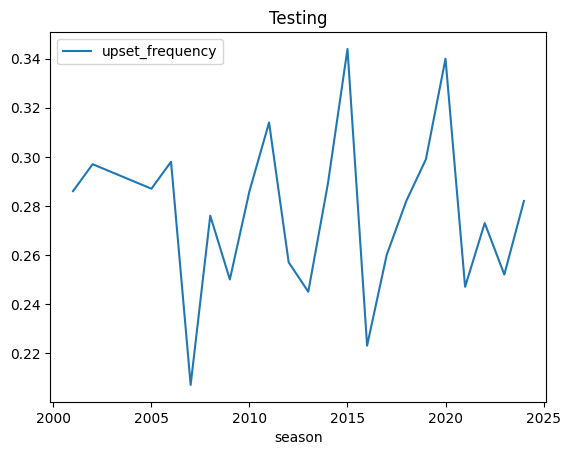

In [ ]:
print("\n" + "=" * 60)
print("2. SEASONAL UPSET FREQUENCY (Sample - Premier League)")
print("=" * 60)

# Test seasonal analysis for Premier League only
pl_data = {'Premier League': league_data['Premier League']}
pl_standings = {'Premier League': standings_data['Premier League']}

seasonal_results = seasonal_upset_frequency(
    pl_data, pl_standings, betting_odds_expectation
)

# Show recent seasons
recent_seasons = seasonal_results[seasonal_results['season'] >= 2020].sort_values(['season'])
print("\nPremier League - Recent Seasons (Betting Odds Predictor):")
print(recent_seasons[['season', 'upset_frequency', 'accuracy', 'total_predictions']].round(3))

print("\n" + "=" * 60)
print("3. TEAM UPSET FREQUENCY (Sample - Top 6 Premier League Teams)")
print("=" * 60)

# Test team analysis for Premier League
team_results = team_upset_frequency(
    pl_data, pl_standings, betting_odds_expectation
)

# Show top teams by overall upset frequency
top_teams = team_results.nlargest(6, 'upset_frequency_overall')
print("\nTop 6 Teams by Overall Upset Frequency (Betting Odds Predictor):")
print(top_teams[['team', 'upset_frequency_overall', 'total_upsets', 'total_predictions']].round(3))

print("\n" + "=" * 60)
print("TESTING COMPLETE")
print("=" * 60)




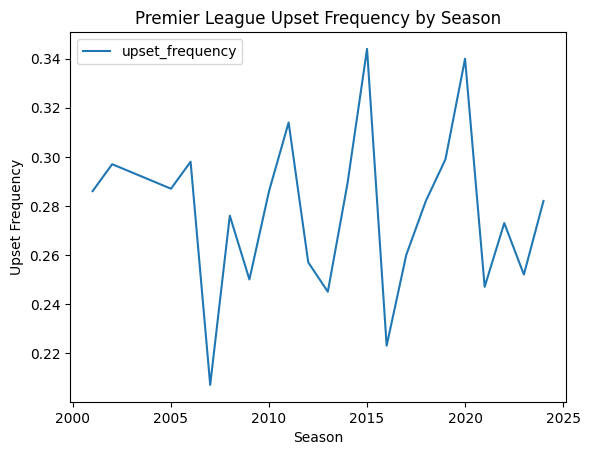

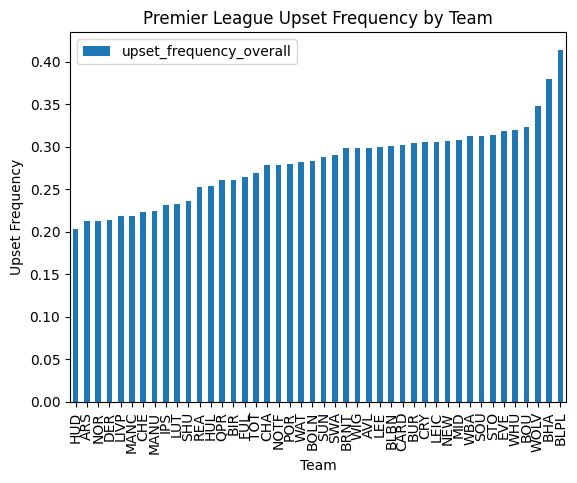

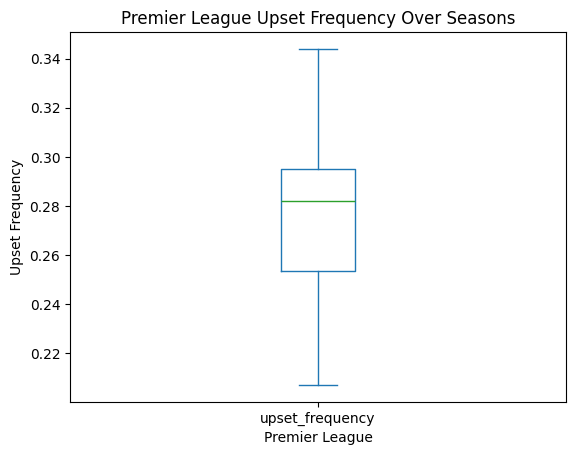

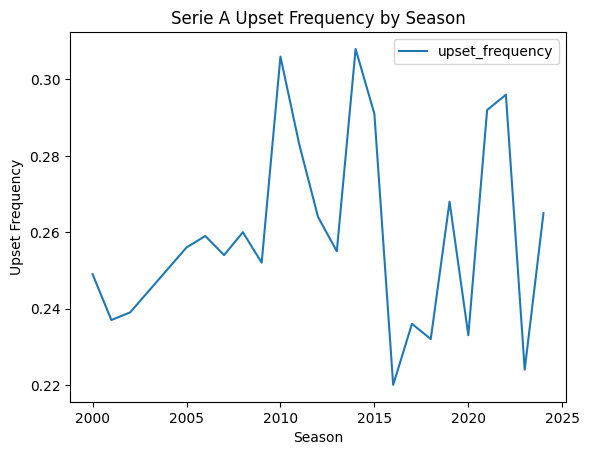

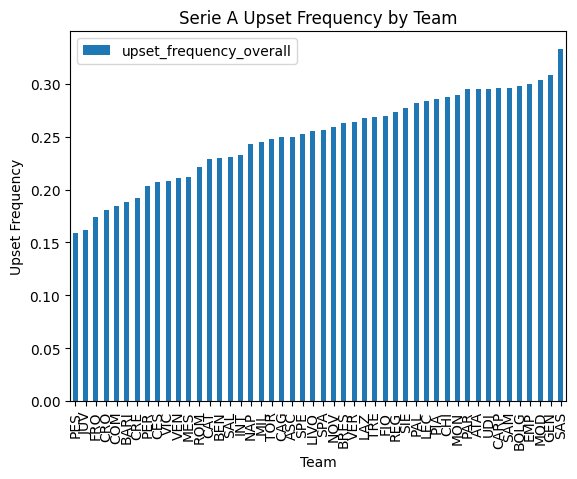

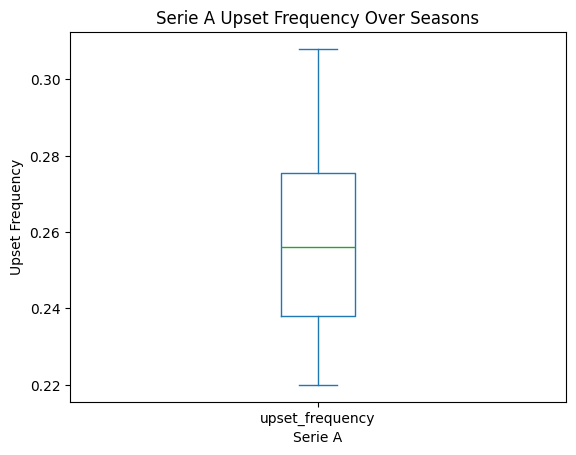

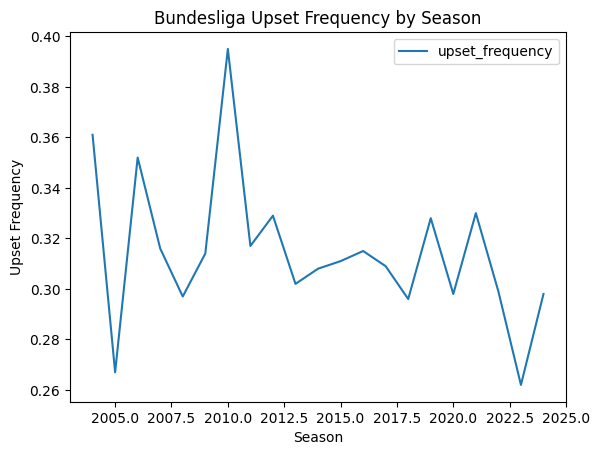

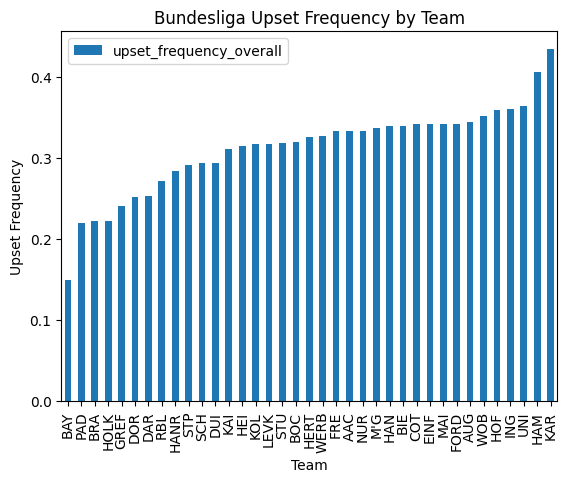

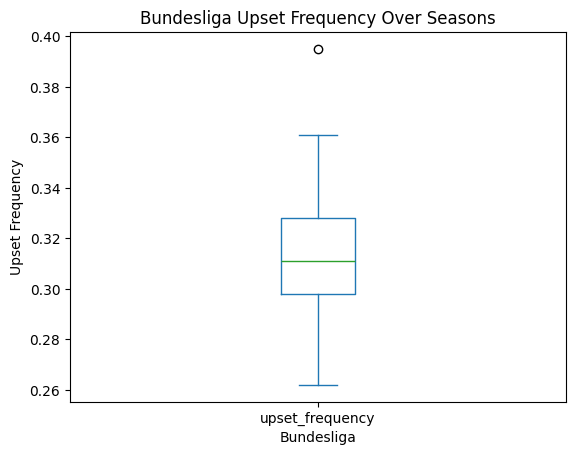

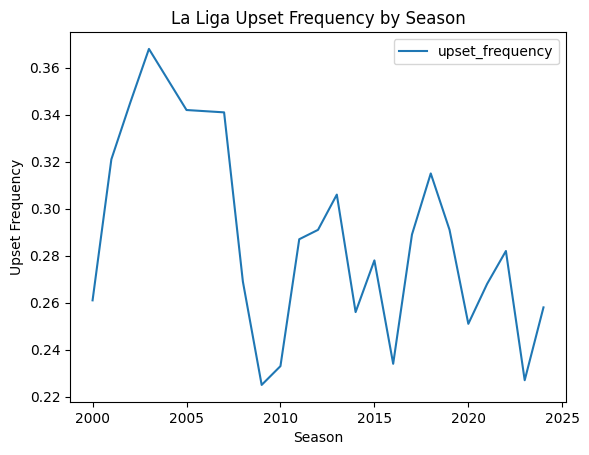

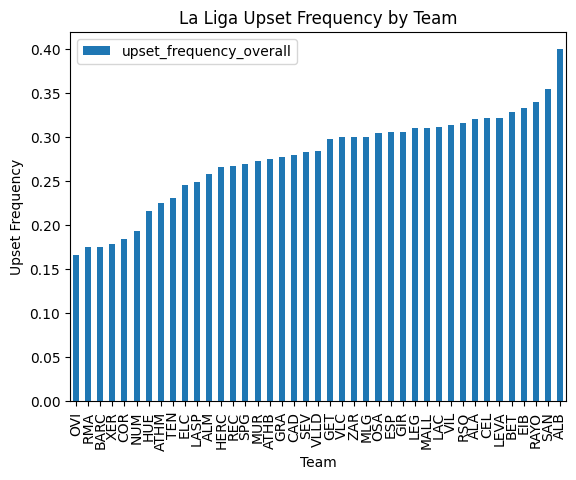

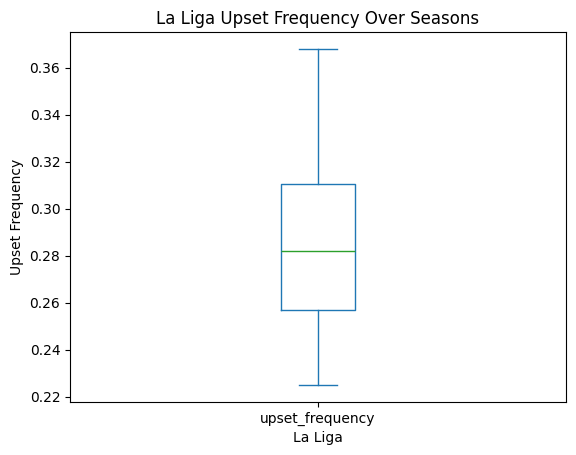

In [44]:
for league in league_data:
    # Test seasonal analysis for Premier League only
    pl_data = {league: league_data[league]}
    pl_standings = {league: standings_data[league]}

    seasonal_results = seasonal_upset_frequency(
        pl_data, pl_standings, betting_odds_expectation
    )

    # Test team analysis for Premier League
    team_results = team_upset_frequency(
        pl_data, pl_standings, betting_odds_expectation
    )
    # seasonal_results.round(3).to_csv(f"{league}_seasonal_upset_frequency.csv".lower())
    # team_results.round(3).to_csv(f"{league}_team_upset_frequency.csv".lower())
    ax = seasonal_results.round(3).plot(x='season', y='upset_frequency', kind='line', title=f"{league} Upset Frequency by Season", xlabel= "Season", ylabel= "Upset Frequency")
    fig = ax.get_figure()
    fig.savefig(f"line_{league}_seasonal_upset_freq.png".lower())

    ax2 = team_results.round(3).sort_values(by = "upset_frequency_overall", ascending=True).plot(x='team', y='upset_frequency_overall', kind='bar', title=f"{league} Upset Frequency by Team", xlabel= "Team", ylabel= "Upset Frequency")
    fig2 = ax2.get_figure()
    fig2.savefig(f"bar_{league}_team_upset_freq.png".lower())

    ax3 = seasonal_results.round(3).plot(x='season', y='upset_frequency', kind='box', title=f"{league} Upset Frequency Over Seasons", xlabel= f"{league}", ylabel= "Upset Frequency")
    fig3 = ax3.get_figure()
    fig3.savefig(f"boxwhisker_{league}_upset_freq.png")
    




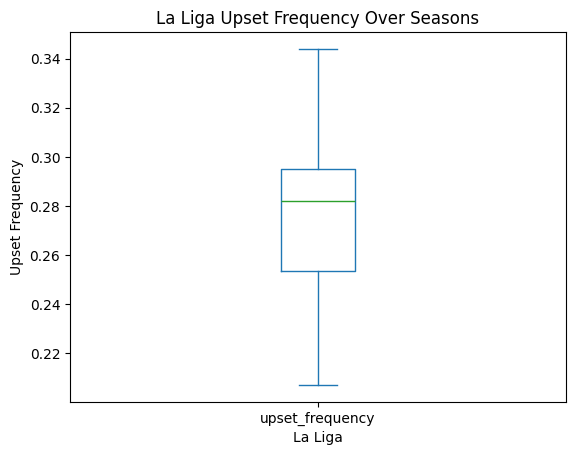

## Usage Summary

The upset frequency functions are now complete and ready to use. Here's how to use them:

### 1. Load Data
```python
league_data, standings_data = load_all_league_data()
```

### 2. Calculate Overall Upset Frequencies by League
```python
# Using betting odds predictor
odds_results = overall_upset_frequency_by_league(
    league_data, standings_data, betting_odds_expectation
)

# Using season ranking predictor
ranking_results = overall_upset_frequency_by_league(
    league_data, standings_data, season_ranking_expectation, standings=None
)
```

### 3. Calculate Seasonal Upset Frequencies
```python
seasonal_results = seasonal_upset_frequency(
    league_data, standings_data, betting_odds_expectation
)
```

### 4. Calculate Team Upset Frequencies
```python
team_results = team_upset_frequency(
    league_data, standings_data, betting_odds_expectation
)
```

### Key Features:
- **Flexible predictor functions**: Can plug in any predictor function that returns +1 (home win expected), -1 (away win expected), or 0 (no prediction)
- **Multi-league support**: Works across all 4 European leagues
- **Comprehensive analysis**: Overall, seasonal, and team-level upset frequencies
- **Robust error handling**: Gracefully handles missing data and edge cases
- **Rich output**: Includes upset frequencies, prediction accuracy, and count statistics